In [1]:
from pils.loader.path import PathLoader
from pils.loader.stout import StoutLoader
from pils.flight import Flight
from pils.analyze.azel import AZELAnalysis

import matplotlib

%matplotlib widget
import matplotlib.pyplot as plt

In [2]:
stout_loader = StoutLoader()

flight_meta = stout_loader.load_single_flight(flight_name="flight_20251208_1927")

flight = Flight(flight_meta)
flight.add_sensor_data(["gps", "inclinometer", "adc"])
flight.add_drone_data()

2026-03-30 15:02:51.885 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 15:02:51 - stout - WARNING - [authenticated_user] - Cannot write to log directory /mnt/data/POLOCALC/logs: [Errno 13] Permission denied: '/mnt/data/POLOCALC/logs/stout.log'. Using console logging only.
2026-03-30 15:02:51,724 - stout - WARNING - Cannot write to log directory /mnt/data/POLOCALC/logs: [Errno 13] Permission denied: '/mnt/data/POLOCALC/logs/stout.log'. Using console logging only.
2026-03-30 15:02:51.886 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-03-30 15:02:51 - stout - INFO - [authenticated_user] - Centralized logging system initialized
2026-03-30 15:02:51,886 - pils.loader.stout - INFO - Initialized with stout database, base path: /mnt/data/POLOC

In [3]:
flight.sync(common_time=False)

2026-03-30 15:02:57,426 - pils.synchronizer - INFO - Set GPS payload reference with 1687 samples
2026-03-30 15:02:57,426 - pils.synchronizer - INFO - Added drone GPS with 8444 samples
2026-03-30 15:02:57,431 - pils.synchronizer - INFO - Added litchi GPS with 6524 samples
2026-03-30 15:02:57,431 - pils.synchronizer - INFO - Added inclinometer with 120499 samples
2026-03-30 15:02:57,431 - pils.synchronizer - INFO - Added payload sensor 'adc' with 1348014 samples
2026-03-30 15:02:57,431 - pils.synchronizer - INFO - Detecting drone GPS offset via NED correlation...
2026-03-30 15:02:57,432 - pils.synchronizer - INFO - Correlation: False False False
2026-03-30 15:02:57,433 - pils.synchronizer - INFO - Correlation: [5.90477885e+06 5.90477885e+06 5.90477885e+06 ... 1.54473921e+00
 1.54281310e+00 1.54283951e+00] [ 9.25253454e+05  9.25253454e+05  9.25253454e+05 ... -2.70594683e+00
 -2.70549560e+00 -2.70536034e+00] [-4.15982160e+06 -4.15982160e+06 -4.15982160e+06 ... -6.56262591e+00
 -6.56008670e

{'drone': shape: (8_444, 42)
 ┌───────────┬──────────┬───────────┬───────────┬───┬───────────┬───────────┬───────────┬───────────┐
 │ tick      ┆ msg_type ┆ GPS:date  ┆ GPS:time  ┆ … ┆ RTK:pos_f ┆ RTK:pos_f ┆ RTK:pos_f ┆ RTK:gps_s │
 │ ---       ┆ ---      ┆ ---       ┆ ---       ┆   ┆ lg_3      ┆ lg_4      ┆ lg_5      ┆ tate      │
 │ i64       ┆ i64      ┆ f64       ┆ f64       ┆   ┆ ---       ┆ ---       ┆ ---       ┆ ---       │
 │           ┆          ┆           ┆           ┆   ┆ f64       ┆ f64       ┆ f64       ┆ f64       │
 ╞═══════════╪══════════╪═══════════╪═══════════╪═══╪═══════════╪═══════════╪═══════════╪═══════════╡
 │ 26308855  ┆ 2096     ┆ 2.0251208 ┆ 192203.0  ┆ … ┆ null      ┆ null      ┆ null      ┆ null      │
 │           ┆          ┆ e7        ┆           ┆   ┆           ┆           ┆           ┆           │
 │ 27063435  ┆ 2096     ┆ 2.0251208 ┆ 192203.0  ┆ … ┆ null      ┆ null      ┆ null      ┆ null      │
 │           ┆          ┆ e7        ┆           ┆   ┆

In [4]:
azel = AZELAnalysis(flight)

result = azel.run_analysis("SATP1", dji_broadcast_geod={'lat': -22.9597732, 'lon': -67.7866847, 'alt': 5173.020})

2026-03-30 15:02:57,527 - pils.analyze.azel - INFO - Initialized AZEL analysis for flight: /mnt/data/POLOCALC/campaigns/202511/20251208/flight_20251208_1927
2026-03-30 15:02:57,527 - pils.analyze.azel - INFO - AZEL directory: /mnt/data/POLOCALC/campaigns/202511/20251208/flight_20251208_1927/proc/azel
2026-03-30 15:02:57,528 - pils.analyze.azel - INFO - Starting AZEL analysis...
2026-03-30 15:02:57,528 - pils.analyze.azel - INFO - Using synchronized drone data from flight.sync_data
2026-03-30 15:02:57,529 - pils.analyze.azel - INFO - Litchi data available in sync_data
2026-03-30 15:02:57,529 - pils.analyze.azel - INFO - Detected drone model: dji
2026-03-30 15:02:57,529 - pils.analyze.azel - INFO - Using drone format: dji, data source: sync_data
2026-03-30 15:02:57,529 - pils.analyze.azel - INFO - Loaded drone data with 8444 rows
2026-03-30 15:02:57,530 - pils.analyze.azel - INFO - Filtered to 8373 valid position samples
2026-03-30 15:02:57,530 - pils.analyze.azel - INFO - Extracted 8373

In [5]:
result.azel_data

timestamp,az,el,srange,E,N,U
f64,f64,f64,f64,f64,f64,f64
1.7652e9,79.686824,-28.927791,6.1649e6,5.3085e6,965983.021496,-2.9820e6
1.7652e9,72.33878,-5.845781,1.2909e6,1.2236e6,389592.936984,-131474.92735
1.7652e9,74.954049,-16.810436,156.740924,144.89911,38.95018,-45.33044
1.7652e9,75.205697,-21.146529,168.11436,151.595785,40.037208,-60.647984
1.7652e9,75.206266,-21.147478,168.116863,151.597469,40.036044,-60.651482
…,…,…,…,…,…,…
1.7652e9,76.148273,-7.257574,159.290492,153.419011,37.830219,-20.123183
1.7652e9,76.149842,-7.25763,159.292565,153.422024,37.826506,-20.1236
1.7652e9,76.149792,-7.257503,159.292247,153.421728,37.826576,-20.123209


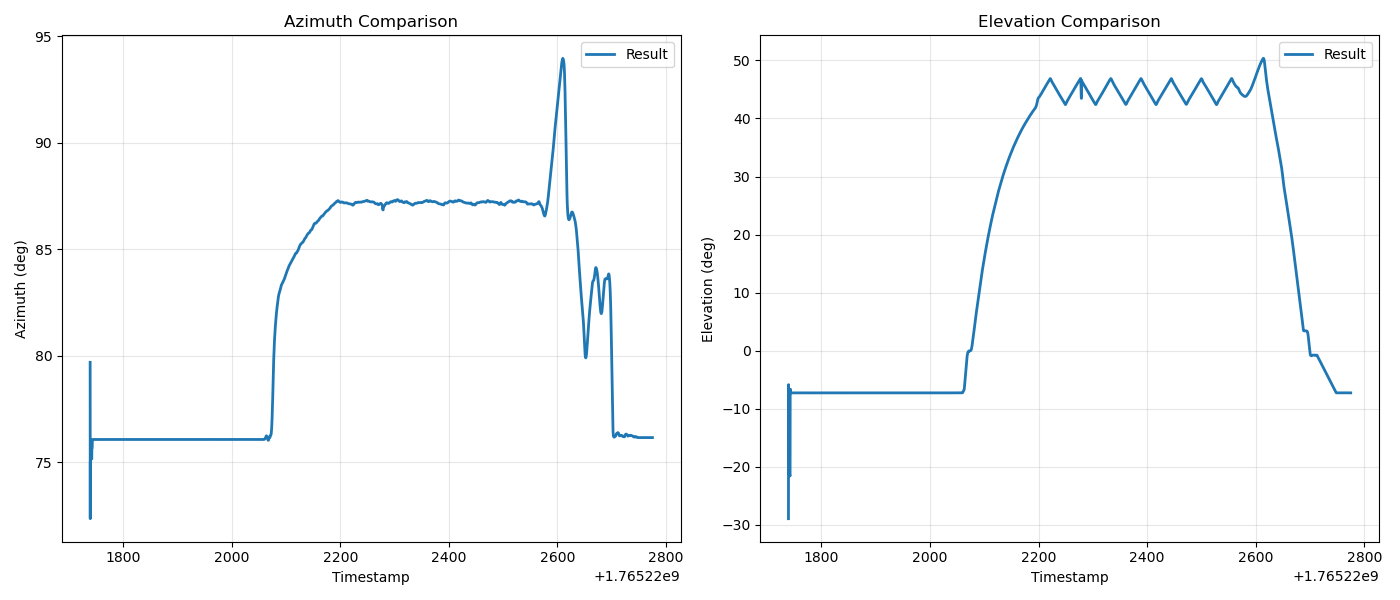

In [ ]:
plt.figure(figsize=(14, 6))

# Azimuth plot
plt.subplot(1, 2, 1)
plt.plot(result.azel_data['timestamp'], result.azel_data['az'], label='Result', linewidth=2)
plt.xlabel('Timestamp')
plt.ylabel('Azimuth (deg)')
plt.title('Azimuth Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Elevation plot
plt.subplot(1, 2, 2)
plt.plot(result.azel_data['timestamp'], result.azel_data['el'], label='Result', linewidth=2)
plt.xlabel('Timestamp')
plt.ylabel('Elevation (deg)')
plt.title('Elevation Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
